# **T02 - Análisis de sensibilidad**
## **Simulación de Procesos Financieros**

---

**Autor:** Francisco Uriel Ledezma Chávez  
**Carrera:** Ingeniería Financiera  
**Institución:** ITESO — Universidad Jesuita de Guadalajara  
**Semestre:** 5° — Simulación de Procesos Financieros  
**Fecha de realización:** 8 de septiembre de 2026

---

En este notebook se valúan opciones europeas call y put mediante simulación Monte Carlo, se contrasta cada resultado con la fórmula analítica de Black-Scholes y se estudia cómo responde el precio de ambos contratos al modificar un parámetro a la vez, con el propósito de identificar cuál de ellos concentra el riesgo de valuación.

## Índice de contenidos

1. Sección 1 — Simulación de puts y calls
2. Sección 2 — Sensibilidad
3. Sección 3 — Visualización
4. Sección 4 — Interpretación
5. Sección 5 — Comparación con el mercado
6. Sección 6 — Conclusiones

## Importación de bibliotecas

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(6)

## 1. Simulación de puts y calls

El precio del activo al vencimiento se genera con el modelo de movimiento browniano geométrico bajo la medida neutral al riesgo, donde el rendimiento esperado es la tasa libre de riesgo y la incertidumbre entra a través de una variable normal estándar.

$$S_T = S_0\exp\left[\left(r - \frac{\sigma^2}{2}\right)T + \sigma\sqrt{T}Z\right], \qquad Z \sim N(0,1)$$

El precio justo de cada opción es el valor presente del pago promedio sobre las trayectorias simuladas, mientras que la fórmula de Black-Scholes ofrece el valor analítico contra el cual se contrasta la simulación.

$$C = e^{-rT}E[\max(S_T - K, 0)], \qquad P = e^{-rT}E[\max(K - S_T, 0)]$$

$$C_{BS} = S_0N(d_1) - Ke^{-rT}N(d_2), \qquad P_{BS} = Ke^{-rT}N(-d_2) - S_0N(-d_1)$$

$$d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

### 1.1 Funciones de pago

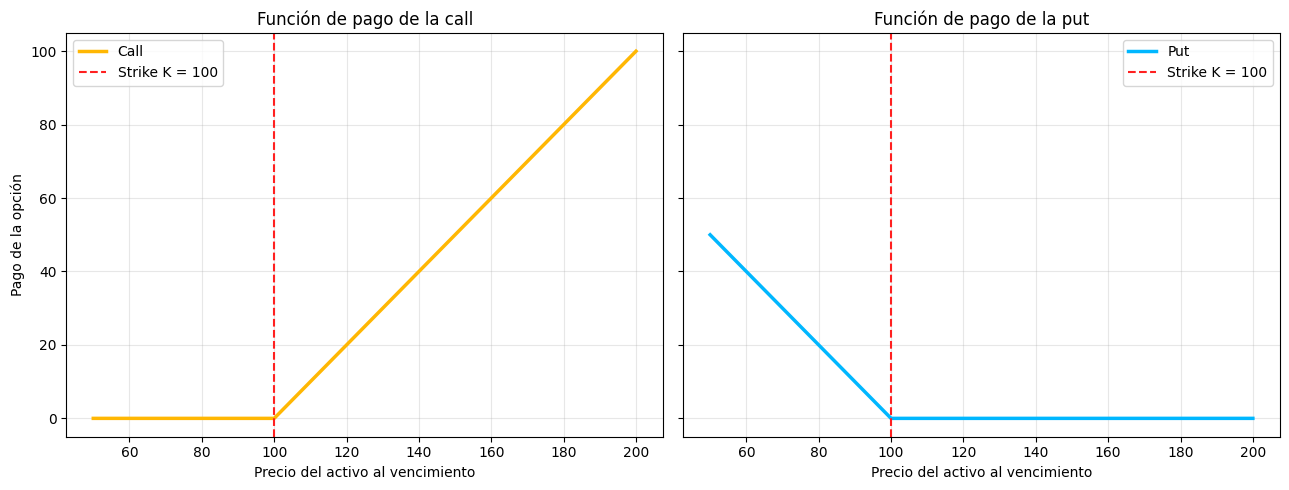

In [19]:
K = 100
precios_vencimiento = np.linspace(50, 200, 100)

pago_call = np.maximum(precios_vencimiento - K, 0)
pago_put = np.maximum(K - precios_vencimiento, 0)

figura, ejes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

ejes[0].plot(precios_vencimiento, pago_call, color="#FFB703", linewidth=2.5, label="Call")
ejes[0].axvline(K, color="#FF2020", linestyle="--", linewidth=1.5, label=f"Strike K = {K}")
ejes[0].set_title("Función de pago de la call")
ejes[0].set_xlabel("Precio del activo al vencimiento")
ejes[0].set_ylabel("Pago de la opción")

ejes[1].plot(precios_vencimiento, pago_put, color="#00B7FF", linewidth=2.5, label="Put")
ejes[1].axvline(K, color="#FF2020", linestyle="--", linewidth=1.5, label=f"Strike K = {K}")
ejes[1].set_title("Función de pago de la put")
ejes[1].set_xlabel("Precio del activo al vencimiento")

for eje in ejes:
    eje.legend()
    eje.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Separadas en dos paneles con la misma escala vertical, las funciones quedan como espejo una de la otra alrededor del strike, ya que la call sólo paga cuando el activo termina por encima de 100 pesos mientras la put paga únicamente por debajo de ese nivel, y en ambos casos el pago se trunca en cero, con lo cual aparece la asimetría que más adelante explica por qué la incertidumbre agrega valor en lugar de restarlo.

### 1.2 Simulación del precio al vencimiento

Los parámetros de partida son los mismos que se utilizaron en clase, con un activo que inicia en 100 pesos, un strike de 100 pesos, una tasa libre de riesgo de 5%, una volatilidad de 20%, un horizonte de un año y 10,000 simulaciones.

La simulación se resuelve pidiendo las 10,000 normales estándar en una sola llamada y evaluando la fórmula sobre el arreglo completo, procedimiento equivalente a extraerlas una por una dentro de un ciclo porque el generador consume el mismo flujo de números en el mismo orden, con la diferencia de que el recorrido ocurre dentro de la biblioteca compilada y no en el intérprete.

Precio promedio simulado al vencimiento: 105.3935
Precio esperado teórico S0*e^(rT):       105.1271
Probabilidad de que la call termine ITM: 0.5665
Probabilidad de que la put termine ITM:  0.4335


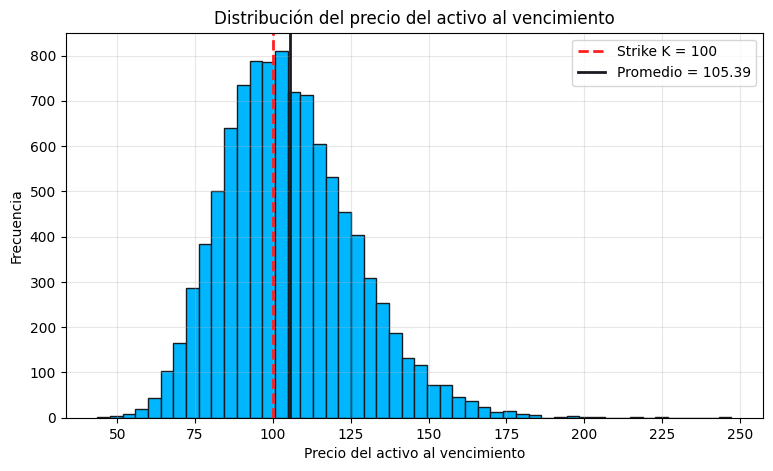

In [20]:
S_0 = 100
r = 0.05
sigma = 0.20
T = 1
numero_simulaciones = 10000

Z = np.random.normal(0, 1, numero_simulaciones)
precios_simulados = S_0 * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z)

precio_esperado_teorico = S_0 * np.exp(r * T)
probabilidad_call_itm = (precios_simulados > K).mean()
probabilidad_put_itm = (precios_simulados < K).mean()

print(f"Precio promedio simulado al vencimiento: {precios_simulados.mean():.4f}")
print(f"Precio esperado teórico S0*e^(rT):       {precio_esperado_teorico:.4f}")
print(f"Probabilidad de que la call termine ITM: {probabilidad_call_itm:.4f}")
print(f"Probabilidad de que la put termine ITM:  {probabilidad_put_itm:.4f}")

plt.figure(figsize=(9, 5))
plt.hist(precios_simulados, bins=50, color="#00B7FF", edgecolor="#1A1B21")
plt.axvline(K, color="#FF2020", linestyle="--", linewidth=2, label=f"Strike K = {K}")
plt.axvline(precios_simulados.mean(), color="#1A1B21", linestyle="-", linewidth=2,
            label=f"Promedio = {precios_simulados.mean():.2f}")

plt.title("Distribución del precio del activo al vencimiento")
plt.xlabel("Precio del activo al vencimiento")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

El promedio simulado de 105.3935 pesos queda 0.2664 pesos por encima del valor teórico $S_0e^{rT} = 105.1271$, diferencia que corresponde al error de muestreo de 10,000 trayectorias y no a un sesgo del modelo, mientras la forma de la distribución muestra la asimetría propia de una lognormal, con 56.65% de los escenarios terminando por encima del strike y 43.35% por debajo, de modo que la call arranca con mayor probabilidad de terminar in-the-money debido a la deriva positiva del proceso.

### 1.3 Precio justo y comparación con Black-Scholes

In [21]:
pagos_call = np.maximum(precios_simulados - K, 0)
pagos_put = np.maximum(K - precios_simulados, 0)

precio_call_mc = np.exp(-r * T) * pagos_call.mean()
precio_put_mc = np.exp(-r * T) * pagos_put.mean()

d1 = (np.log(S_0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

precio_call_bs = S_0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
precio_put_bs = K * np.exp(-r * T) * norm.cdf(-d2) - S_0 * norm.cdf(-d1)

print(f"{'Opción':<10}{'Monte Carlo':>14}{'Black-Scholes':>16}{'Diferencia':>14}{'Error %':>12}")
print(f"{'Call':<10}{precio_call_mc:>14.4f}{precio_call_bs:>16.4f}"
      f"{abs(precio_call_mc - precio_call_bs):>14.4f}"
      f"{100 * abs(precio_call_mc - precio_call_bs) / precio_call_bs:>12.4f}")
print(f"{'Put':<10}{precio_put_mc:>14.4f}{precio_put_bs:>16.4f}"
      f"{abs(precio_put_mc - precio_put_bs):>14.4f}"
      f"{100 * abs(precio_put_mc - precio_put_bs) / precio_put_bs:>12.4f}")

Opción       Monte Carlo   Black-Scholes    Diferencia     Error %
Call             10.5654         10.4506        0.1148      1.0987
Put               5.4349          5.5735        0.1386      2.4868


La simulación entrega 10.5654 pesos para la call y 5.4349 para la put frente a los 10.4506 y 5.5735 que produce Black-Scholes, con errores relativos de 1.10% y 2.49% que confirman la convergencia del estimador sin alcanzar el valor exacto, ya que la brecha proviene del muestreo finito y no de una discrepancia entre ambos enfoques, además el error relativo mayor de la put no indica peor estimación sino menor base de comparación, pues su desviación absoluta de 0.1386 pesos es prácticamente la misma que los 0.1148 de la call.

### 1.4 Verificación de la paridad put-call

La paridad put-call establece una relación de no arbitraje entre ambos contratos, por lo que sirve como prueba interna de consistencia de los precios estimados.

$$C - P = S_0 - Ke^{-rT}$$

In [22]:
lado_izquierdo = precio_call_mc - precio_put_mc
lado_derecho = S_0 - K * np.exp(-r * T)

print(f"C - P (Monte Carlo): {lado_izquierdo:.4f}")
print(f"S0 - K*e^(-rT):      {lado_derecho:.4f}")
print(f"Diferencia:          {abs(lado_izquierdo - lado_derecho):.4f}")

C - P (Monte Carlo): 5.1305
S0 - K*e^(-rT):      4.8771
Diferencia:          0.2534


La relación no se cumple de manera exacta, ya que la diferencia de 0.2534 pesos representa 5.20% del valor teórico, aunque su origen es completamente rastreable, pues al calcularse ambos precios sobre las mismas trayectorias la resta $C - P$ se reduce a $e^{-rT}(\bar{S}_T - K)$, de modo que el residual coincide con el descuento de los 0.2664 pesos en que el promedio simulado excede a $S_0e^{rT}$, con ello la paridad se sostiene de forma algebraica y lo único que queda a la vista es el error de muestreo del promedio del activo.

## 2. Sensibilidad

El análisis modifica un parámetro a la vez y mantiene los demás en su valor base, con lo cual el cambio observado en el precio se atribuye únicamente a la variable que se movió. Cada escenario se vuelve a simular con 10,000 trayectorias y se acompaña del valor analítico de Black-Scholes, ya que sin ese contraste no habría manera de distinguir entre un efecto real del parámetro y el ruido propio del método de simulación.

### 2.1 Precio del activo

In [23]:
valores_activo = [80, 90, 100, 110, 120]
call_activo = []
put_activo = []
call_activo_bs = []
put_activo_bs = []

for valor in valores_activo:
    Z = np.random.normal(0, 1, numero_simulaciones)
    S_T = valor * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z)

    call_activo.append(np.exp(-r * T) * np.maximum(S_T - K, 0).mean())
    put_activo.append(np.exp(-r * T) * np.maximum(K - S_T, 0).mean())

    d1 = (np.log(valor / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_activo_bs.append(valor * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2))
    put_activo_bs.append(K * np.exp(-r * T) * norm.cdf(-d2) - valor * norm.cdf(-d1))

print(f"{'S0':>8}{'Call MC':>12}{'Call BS':>12}{'Put MC':>12}{'Put BS':>12}")
for i in range(len(valores_activo)):
    print(f"{valores_activo[i]:>8}{call_activo[i]:>12.4f}{call_activo_bs[i]:>12.4f}"
          f"{put_activo[i]:>12.4f}{put_activo_bs[i]:>12.4f}")

      S0     Call MC     Call BS      Put MC      Put BS
      80      1.7373      1.8594     17.1015     16.9824
      90      5.1260      5.0912     10.2867     10.2142
     100     10.2156     10.4506      5.6323      5.5735
     110     17.2884     17.6630      2.8024      2.7859
     120     26.1417     26.1690      1.2746      1.2920


El precio de la call pasa de 1.7373 a 26.1417 pesos cuando el activo sube de 80 a 120, un incremento de quince veces, mientras la put recorre el camino contrario al caer de 17.1015 a 1.2746 pesos, y ambas columnas reproducen los valores analíticos con una desviación máxima de 0.3746 pesos, salvo en el extremo de 80 donde la call registra 6.57% de error relativo por tratarse del precio más pequeño de la tabla.

El renglón de 100 pesos no reproduce el precio obtenido en la sección 1.3 porque cada escenario se vuelve a simular con trayectorias nuevas, así que la distancia entre 10.2156 y 10.5654 mide la dispersión del estimador entre corridas y no un cambio en el parámetro, razón por la cual la columna de Black-Scholes acompaña a cada tabla y sirve como referencia fija.

### 2.2 Strike

In [24]:
valores_strike = [80, 90, 100, 110, 120]
call_strike = []
put_strike = []
call_strike_bs = []
put_strike_bs = []
itm_call_strike = []
itm_put_strike = []

for valor in valores_strike:
    Z = np.random.normal(0, 1, numero_simulaciones)
    precios_finales = S_0 * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z)

    call_strike.append(np.exp(-r * T) * np.maximum(precios_finales - valor, 0).mean())
    put_strike.append(np.exp(-r * T) * np.maximum(valor - precios_finales, 0).mean())
    itm_call_strike.append((precios_finales > valor).mean())
    itm_put_strike.append((precios_finales < valor).mean())

    d1 = (np.log(S_0 / valor) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_strike_bs.append(S_0 * norm.cdf(d1) - valor * np.exp(-r * T) * norm.cdf(d2))
    put_strike_bs.append(valor * np.exp(-r * T) * norm.cdf(-d2) - S_0 * norm.cdf(-d1))

print(f"{'K':>8}{'Call MC':>12}{'Call BS':>12}{'Put MC':>12}{'Put BS':>12}"
      f"{'ITM call':>12}{'ITM put':>12}")
for i in range(len(valores_strike)):
    print(f"{valores_strike[i]:>8}{call_strike[i]:>12.4f}{call_strike_bs[i]:>12.4f}"
          f"{put_strike[i]:>12.4f}{put_strike_bs[i]:>12.4f}"
          f"{itm_call_strike[i]:>12.4f}{itm_put_strike[i]:>12.4f}")

       K     Call MC     Call BS      Put MC      Put BS    ITM call     ITM put
      80     24.3058     24.5888      0.7048      0.6872      0.8919      0.1081
      90     16.7393     16.6994      2.2802      2.3101      0.7582      0.2418
     100     10.7518     10.4506      5.5534      5.5735      0.5641      0.4359
     110      5.9487      6.0401     10.7407     10.6753      0.3673      0.6327
     120      3.3519      3.2475     17.5362     17.3950      0.2224      0.7776


Un strike más alto reduce el valor de la call de 24.3058 a 3.3519 pesos y eleva el de la put de 0.7048 a 17.5362, movimiento que la probabilidad de terminar in-the-money explica de manera directa, ya que la call desciende de 89.19% a 22.24% mientras la put recorre el trayecto inverso de 10.81% a 77.76%, y a esa caída en frecuencia se suma una caída en magnitud, debido a que cada escenario ganador de la call paga su diferencia contra un umbral mayor.

### 2.3 Volatilidad

In [25]:
valores_volatilidad = [0.10, 0.20, 0.30, 0.40, 0.50]
call_volatilidad = []
put_volatilidad = []
call_volatilidad_bs = []
put_volatilidad_bs = []

for valor in valores_volatilidad:
    Z = np.random.normal(0, 1, numero_simulaciones)
    S_T = S_0 * np.exp((r - 0.5 * valor ** 2) * T + valor * np.sqrt(T) * Z)

    call_volatilidad.append(np.exp(-r * T) * np.maximum(S_T - K, 0).mean())
    put_volatilidad.append(np.exp(-r * T) * np.maximum(K - S_T, 0).mean())

    d1 = (np.log(S_0 / K) + (r + 0.5 * valor ** 2) * T) / (valor * np.sqrt(T))
    d2 = d1 - valor * np.sqrt(T)
    call_volatilidad_bs.append(S_0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2))
    put_volatilidad_bs.append(K * np.exp(-r * T) * norm.cdf(-d2) - S_0 * norm.cdf(-d1))

print(f"{'sigma':>8}{'Call MC':>12}{'Call BS':>12}{'Put MC':>12}{'Put BS':>12}")
for i in range(len(valores_volatilidad)):
    print(f"{valores_volatilidad[i]:>8.2f}{call_volatilidad[i]:>12.4f}"
          f"{call_volatilidad_bs[i]:>12.4f}{put_volatilidad[i]:>12.4f}"
          f"{put_volatilidad_bs[i]:>12.4f}")

   sigma     Call MC     Call BS      Put MC      Put BS
    0.10      6.7716      6.8050      1.9413      1.9279
    0.20     10.5148     10.4506      5.4534      5.5735
    0.30     14.6474     14.2313      9.3174      9.3542
    0.40     18.1370     18.0230     13.0460     13.1459
    0.50     21.5591     21.7926     17.0818     16.9155


La volatilidad es el único parámetro que empuja ambos contratos en la misma dirección, pues al pasar de 10% a 50% la call se multiplica por 3.18 hasta 21.5591 pesos y la put por 8.80 hasta 17.0818, y el mayor efecto proporcional sobre la put no la vuelve más sensible en términos absolutos, sino que refleja su punto de partida de apenas 1.9413 pesos con la deriva del activo jugando en su contra.

El escenario de 30% concentra la mayor discrepancia frente a Black-Scholes de toda la tarea, con 0.4161 pesos equivalentes a 2.92%, resultado consistente con que la varianza del estimador crece junto con la volatilidad del proceso simulado, por ello el mismo número de trayectorias rinde estimaciones menos precisas conforme el parámetro aumenta.

### 2.4 Tiempo al vencimiento

In [26]:
valores_tiempo = [0.25, 0.5, 1, 1.5, 2]
call_tiempo = []
put_tiempo = []
call_tiempo_bs = []
put_tiempo_bs = []

for valor in valores_tiempo:
    Z = np.random.normal(0, 1, numero_simulaciones)
    S_T = S_0 * np.exp((r - 0.5 * sigma ** 2) * valor + sigma * np.sqrt(valor) * Z)

    call_tiempo.append(np.exp(-r * valor) * np.maximum(S_T - K, 0).mean())
    put_tiempo.append(np.exp(-r * valor) * np.maximum(K - S_T, 0).mean())

    d1 = (np.log(S_0 / K) + (r + 0.5 * sigma ** 2) * valor) / (sigma * np.sqrt(valor))
    d2 = d1 - sigma * np.sqrt(valor)
    call_tiempo_bs.append(S_0 * norm.cdf(d1) - K * np.exp(-r * valor) * norm.cdf(d2))
    put_tiempo_bs.append(K * np.exp(-r * valor) * norm.cdf(-d2) - S_0 * norm.cdf(-d1))

print(f"{'T':>8}{'Call MC':>12}{'Call BS':>12}{'Put MC':>12}{'Put BS':>12}")
for i in range(len(valores_tiempo)):
    print(f"{valores_tiempo[i]:>8.2f}{call_tiempo[i]:>12.4f}{call_tiempo_bs[i]:>12.4f}"
          f"{put_tiempo[i]:>12.4f}{put_tiempo_bs[i]:>12.4f}")

       T     Call MC     Call BS      Put MC      Put BS
    0.25      4.5716      4.6150      3.4272      3.3728
    0.50      6.8010      6.8887      4.4838      4.4197
    1.00     10.4074     10.4506      5.5308      5.5735
    1.50     13.4308     13.4429      6.3923      6.2173
    2.00     15.8140     16.1268      6.7267      6.6105


El plazo agrega valor a los dos contratos, aunque de forma marcadamente desigual, ya que la call sube de 4.5716 a 15.8140 pesos entre 0.25 y 2 años mientras la put apenas avanza de 3.4272 a 6.7267, y el crecimiento tampoco es proporcional al tiempo porque la dispersión del proceso escala con $\sqrt{T}$, de modo que duplicar el plazo de uno a dos años multiplica la call solamente por 1.52.

En la put el efecto casi se agota, con un avance de 21.62% en ese mismo tramo, debido a que el plazo adicional amplía la dispersión a su favor pero al mismo tiempo descuenta con más fuerza el strike que eventualmente recibiría, con lo cual ambas fuerzas se compensan y la curva se aplana.

### 2.5 Rendimiento

In [27]:
valores_rendimiento = [0.05, 0.10, 0.15, 0.20]
call_rendimiento = []
put_rendimiento = []
call_rendimiento_bs = []
put_rendimiento_bs = []

for valor in valores_rendimiento:
    Z = np.random.normal(0, 1, numero_simulaciones)
    S_T = S_0 * np.exp((valor - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z)

    call_rendimiento.append(np.exp(-valor * T) * np.maximum(S_T - K, 0).mean())
    put_rendimiento.append(np.exp(-valor * T) * np.maximum(K - S_T, 0).mean())

    d1 = (np.log(S_0 / K) + (valor + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_rendimiento_bs.append(S_0 * norm.cdf(d1) - K * np.exp(-valor * T) * norm.cdf(d2))
    put_rendimiento_bs.append(K * np.exp(-valor * T) * norm.cdf(-d2) - S_0 * norm.cdf(-d1))

print(f"{'r':>8}{'Call MC':>12}{'Call BS':>12}{'Put MC':>12}{'Put BS':>12}")
for i in range(len(valores_rendimiento)):
    print(f"{valores_rendimiento[i]:>8.2f}{call_rendimiento[i]:>12.4f}"
          f"{call_rendimiento_bs[i]:>12.4f}{put_rendimiento[i]:>12.4f}"
          f"{put_rendimiento_bs[i]:>12.4f}")

       r     Call MC     Call BS      Put MC      Put BS
    0.05     10.4566     10.4506      5.4484      5.5735
    0.10     13.1967     13.2697      3.7392      3.7534
    0.15     16.2014     16.3560      2.3609      2.4268
    0.20     20.0258     19.6299      1.4694      1.5030


Una tasa más alta desplaza el valor esperado del activo hacia arriba y abarata el strike en valor presente, por ello la call casi se duplica al pasar de 10.4566 a 20.0258 pesos entre 5% y 20% mientras la put se reduce de 5.4484 a 1.4694, y conviene subrayar que esta tasa no representa un rendimiento esperado del mercado sino el parámetro de la medida neutral al riesgo, ya que bajo esa medida la deriva del activo se fija en $r$ y el descuento se realiza con esa misma tasa.

## 3. Visualización

Cada gráfica reúne el precio de la call y el de la put frente al mismo parámetro, de modo que la comparación entre ambas curvas revela si el efecto es simétrico entre las dos posiciones o si las mueve en la misma dirección.

A diferencia de las tablas anteriores, aquí el parámetro recorre una malla fina con paso de 0.01 sobre las variables medidas en pesos, lo cual produce 4,002 evaluaciones para el precio del activo y otras tantas para el strike, mientras que en volatilidad y rendimiento el paso baja a 0.001 porque un incremento de 0.01 dejaría apenas 41 y 16 puntos sobre rangos que van de 10% a 50% y de 5% a 20%.

Ese nivel de detalle obliga a un cambio en el procedimiento, ya que extraer 10,000 trayectorias nuevas en cada uno de los 4,002 puntos multiplicaría el cómputo sin ganancia alguna, por ello se genera una sola muestra de normales estándar que se reutiliza en todas las evaluaciones, y la ventaja principal no es de tiempo sino de lectura, dado que al compartir la muestra la diferencia entre dos evaluaciones contiguas responde únicamente al parámetro y no al azar, con lo cual la curva sale limpia en lugar de temblorosa.

In [28]:
Z_comun = np.random.normal(0, 1, numero_simulaciones)

### 3.1 Precio de la opción frente al precio del activo

Puntos evaluados: 4002
Cruce de las curvas en S0 = 95.11
Valor teórico del cruce K*e^(-rT) = 95.1229


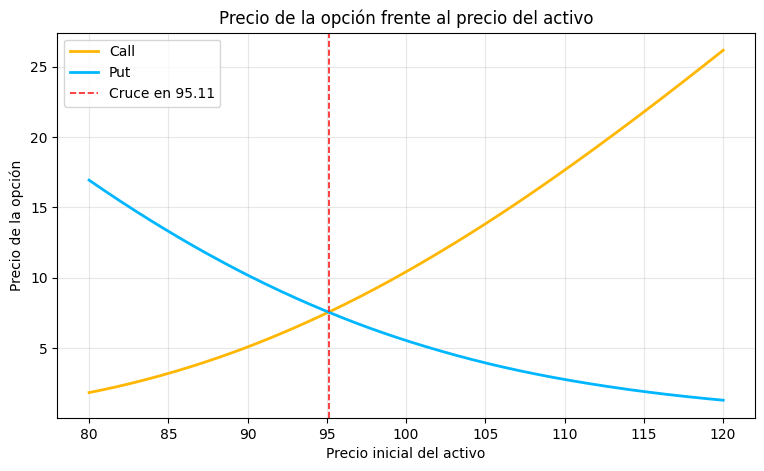

In [29]:
malla_activo = np.arange(80, 120.01, 0.01)
curva_call_activo = []
curva_put_activo = []

for valor in malla_activo:
    S_T = valor * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z_comun)
    curva_call_activo.append(np.exp(-r * T) * np.maximum(S_T - K, 0).mean())
    curva_put_activo.append(np.exp(-r * T) * np.maximum(K - S_T, 0).mean())

curva_call_activo = np.array(curva_call_activo)
curva_put_activo = np.array(curva_put_activo)

cruce_activo = malla_activo[np.argmin(np.abs(curva_call_activo - curva_put_activo))]
print(f"Puntos evaluados: {len(malla_activo)}")
print(f"Cruce de las curvas en S0 = {cruce_activo:.2f}")
print(f"Valor teórico del cruce K*e^(-rT) = {K * np.exp(-r * T):.4f}")

plt.figure(figsize=(9, 5))
plt.plot(malla_activo, curva_call_activo, linewidth=2, color="#FFB703", label="Call")
plt.plot(malla_activo, curva_put_activo, linewidth=2, color="#00B7FF", label="Put")
plt.axvline(cruce_activo, color="#FF2020", linestyle="--", linewidth=1.2,
            label=f"Cruce en {cruce_activo:.2f}")

plt.title("Precio de la opción frente al precio del activo")
plt.xlabel("Precio inicial del activo")
plt.ylabel("Precio de la opción")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Las dos curvas se cruzan en 95.11 pesos y presentan pendientes de signo opuesto, con la call creciente y convexa frente a la put decreciente que se aplana conforme el activo se aleja hacia arriba, comportamiento que corresponde a una delta positiva para la primera y negativa para la segunda.

El punto de cruce no es arbitrario, ya que la paridad exige que ambos contratos valgan lo mismo cuando $S_0 = Ke^{-rT} = 95.1229$, de modo que la malla fina recupera ese valor con un error de un centavo y confirma que la relación teórica se sostiene a lo largo de todo el rango y no sólo en el caso base de la sección 1.4.

### 3.2 Precio de la opción frente al strike

Puntos evaluados: 4002
Cruce de las curvas en K = 105.14
Valor teórico del cruce S0*e^(rT) = 105.1271


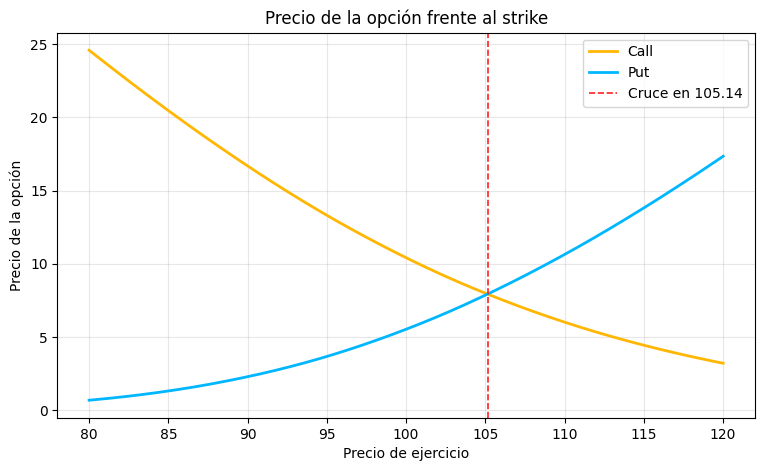

In [30]:
malla_strike = np.arange(80, 120.01, 0.01)
curva_call_strike = []
curva_put_strike = []

precios_comunes = S_0 * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z_comun)

for valor in malla_strike:
    curva_call_strike.append(np.exp(-r * T) * np.maximum(precios_comunes - valor, 0).mean())
    curva_put_strike.append(np.exp(-r * T) * np.maximum(valor - precios_comunes, 0).mean())

curva_call_strike = np.array(curva_call_strike)
curva_put_strike = np.array(curva_put_strike)

cruce_strike = malla_strike[np.argmin(np.abs(curva_call_strike - curva_put_strike))]
print(f"Puntos evaluados: {len(malla_strike)}")
print(f"Cruce de las curvas en K = {cruce_strike:.2f}")
print(f"Valor teórico del cruce S0*e^(rT) = {S_0 * np.exp(r * T):.4f}")

plt.figure(figsize=(9, 5))
plt.plot(malla_strike, curva_call_strike, linewidth=2, color="#FFB703", label="Call")
plt.plot(malla_strike, curva_put_strike, linewidth=2, color="#00B7FF", label="Put")
plt.axvline(cruce_strike, color="#FF2020", linestyle="--", linewidth=1.2,
            label=f"Cruce en {cruce_strike:.2f}")

plt.title("Precio de la opción frente al strike")
plt.xlabel("Precio de ejercicio")
plt.ylabel("Precio de la opción")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

La imagen es el reflejo de la anterior, ya que subir el strike equivale a alejar el activo hacia abajo en términos relativos, con ello la call desciende y la put asciende hasta cruzarse en 105.14 pesos, valor que reproduce la predicción $S_0e^{rT} = 105.1271$ derivada de esa misma condición de paridad.

### 3.3 Precio de la opción frente a la volatilidad

Puntos evaluados: 401


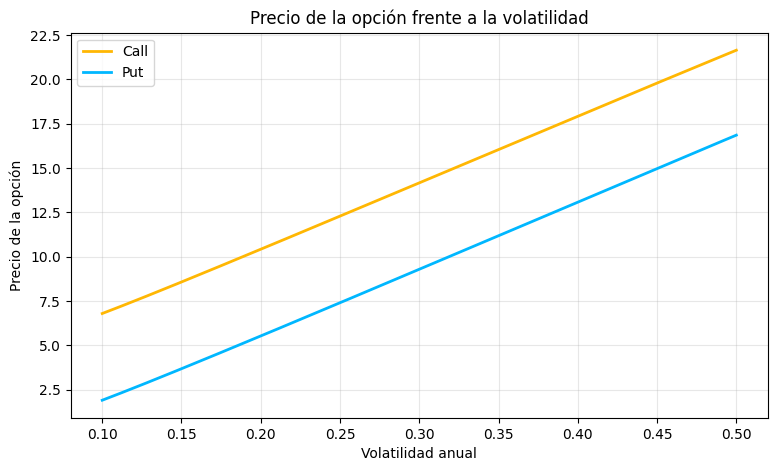

In [31]:
malla_volatilidad = np.arange(0.10, 0.5001, 0.001)
curva_call_volatilidad = []
curva_put_volatilidad = []

for valor in malla_volatilidad:
    S_T = S_0 * np.exp((r - 0.5 * valor ** 2) * T + valor * np.sqrt(T) * Z_comun)
    curva_call_volatilidad.append(np.exp(-r * T) * np.maximum(S_T - K, 0).mean())
    curva_put_volatilidad.append(np.exp(-r * T) * np.maximum(K - S_T, 0).mean())

print(f"Puntos evaluados: {len(malla_volatilidad)}")

plt.figure(figsize=(9, 5))
plt.plot(malla_volatilidad, curva_call_volatilidad, linewidth=2, color="#FFB703", label="Call")
plt.plot(malla_volatilidad, curva_put_volatilidad, linewidth=2, color="#00B7FF", label="Put")

plt.title("Precio de la opción frente a la volatilidad")
plt.xlabel("Volatilidad anual")
plt.ylabel("Precio de la opción")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Ambas líneas ascienden juntas y con una curvatura apenas perceptible dentro de este rango, sin cruzarse ni invertir su pendiente, lo cual distingue a la volatilidad del resto de los parámetros y confirma que no existe cobertura natural entre call y put frente a este factor.

### 3.4 Precio de la opción frente al tiempo

Puntos evaluados: 176
Plazo con el mayor valor de la put dentro del rango: 2.00 años


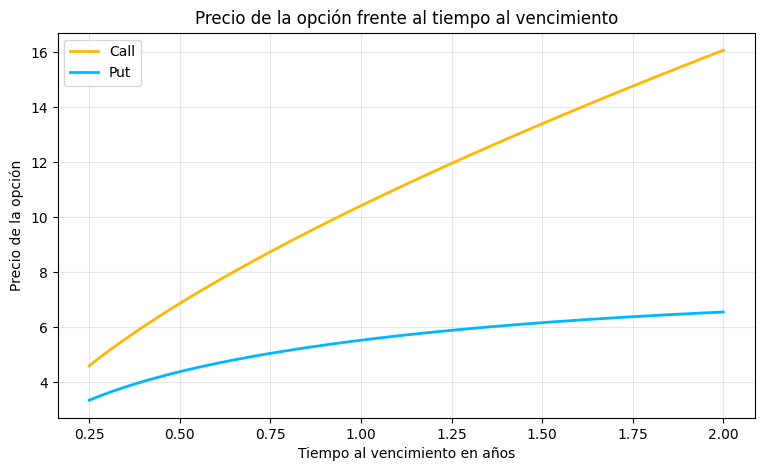

In [32]:
malla_tiempo = np.arange(0.25, 2.001, 0.01)
curva_call_tiempo = []
curva_put_tiempo = []

for valor in malla_tiempo:
    S_T = S_0 * np.exp((r - 0.5 * sigma ** 2) * valor + sigma * np.sqrt(valor) * Z_comun)
    curva_call_tiempo.append(np.exp(-r * valor) * np.maximum(S_T - K, 0).mean())
    curva_put_tiempo.append(np.exp(-r * valor) * np.maximum(K - S_T, 0).mean())

curva_put_tiempo = np.array(curva_put_tiempo)
tiempo_maximo_put = malla_tiempo[np.argmax(curva_put_tiempo)]

print(f"Puntos evaluados: {len(malla_tiempo)}")
print(f"Plazo con el mayor valor de la put dentro del rango: {tiempo_maximo_put:.2f} años")

plt.figure(figsize=(9, 5))
plt.plot(malla_tiempo, curva_call_tiempo, linewidth=2, color="#FFB703", label="Call")
plt.plot(malla_tiempo, curva_put_tiempo, linewidth=2, color="#00B7FF", label="Put")

plt.title("Precio de la opción frente al tiempo al vencimiento")
plt.xlabel("Tiempo al vencimiento en años")
plt.ylabel("Precio de la opción")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

La curva de la call crece con concavidad decreciente mientras la de la put se aplana de manera notoria después del primer año, imagen que resume la compensación entre una mayor dispersión y un descuento más severo del strike, y conviene precisar que ese aplanamiento no llega a convertirse en descenso, ya que el mayor valor de la put dentro de la malla aparece en el extremo de 2 años y no en un punto interior.

### 3.5 Precio de la opción frente al rendimiento

Puntos evaluados: 151


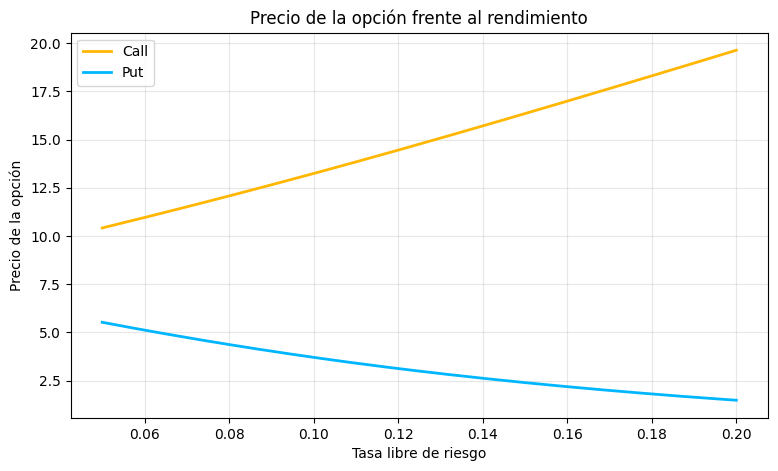

In [33]:
malla_rendimiento = np.arange(0.05, 0.2001, 0.001)
curva_call_rendimiento = []
curva_put_rendimiento = []

for valor in malla_rendimiento:
    S_T = S_0 * np.exp((valor - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z_comun)
    curva_call_rendimiento.append(np.exp(-valor * T) * np.maximum(S_T - K, 0).mean())
    curva_put_rendimiento.append(np.exp(-valor * T) * np.maximum(K - S_T, 0).mean())

print(f"Puntos evaluados: {len(malla_rendimiento)}")

plt.figure(figsize=(9, 5))
plt.plot(malla_rendimiento, curva_call_rendimiento, linewidth=2, color="#FFB703", label="Call")
plt.plot(malla_rendimiento, curva_put_rendimiento, linewidth=2, color="#00B7FF", label="Put")

plt.title("Precio de la opción frente al rendimiento")
plt.xlabel("Tasa libre de riesgo")
plt.ylabel("Precio de la opción")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Las pendientes vuelven a ser opuestas, con la call subiendo de forma casi lineal y la put acercándose a cero, aunque el rango de precios recorrido es menor que el observado al mover el activo, lo cual adelanta que la tasa pesa menos que los demás factores dentro de un horizonte de un año.

### 3.6 Panorama conjunto

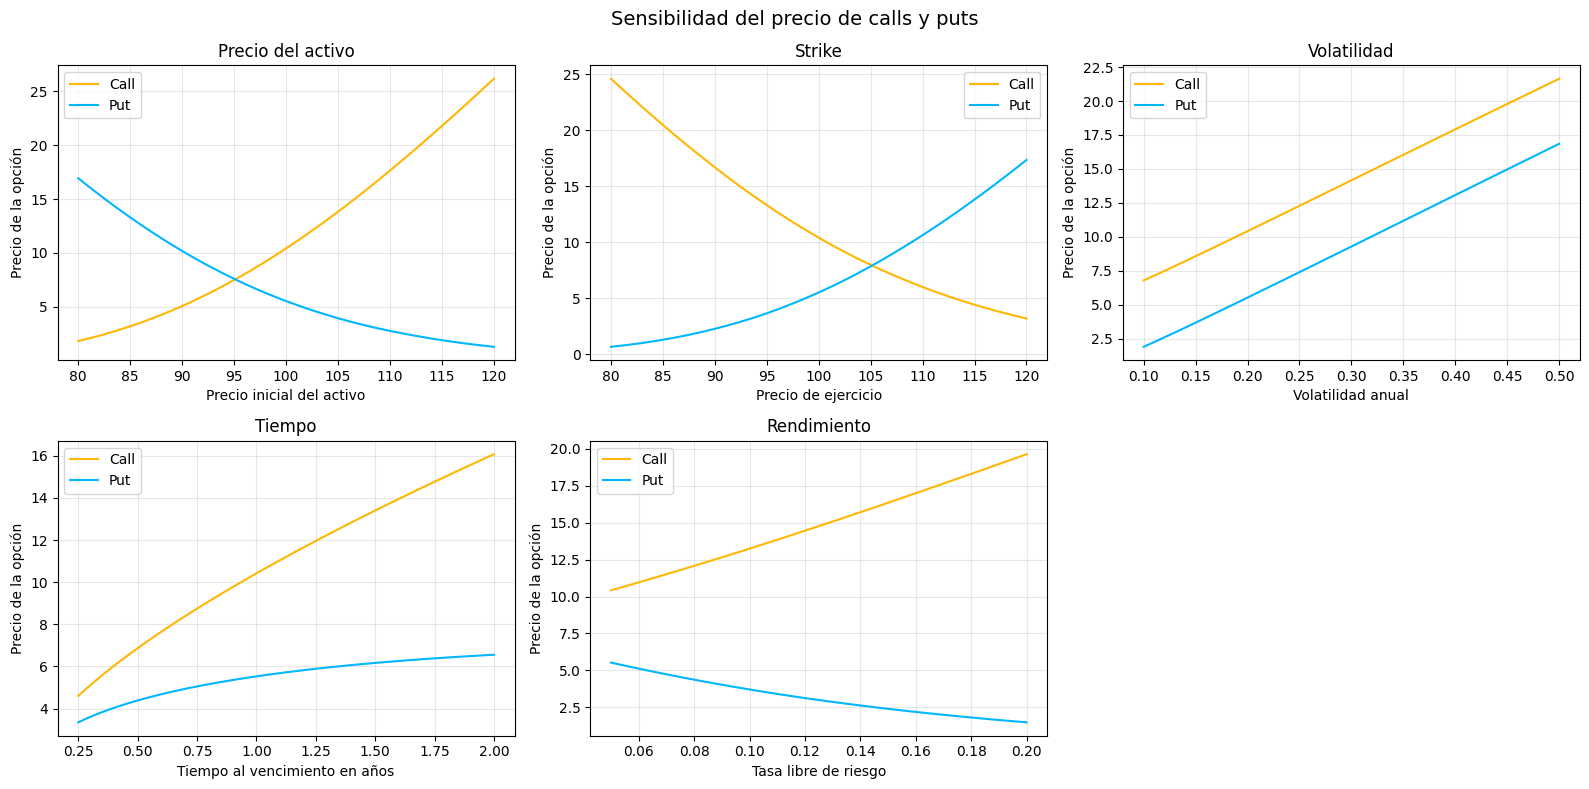

In [34]:
figura, ejes = plt.subplots(2, 3, figsize=(16, 8))

ejes[0, 0].plot(malla_activo, curva_call_activo, color="#FFB703", label="Call")
ejes[0, 0].plot(malla_activo, curva_put_activo, color="#00B7FF", label="Put")
ejes[0, 0].set_title("Precio del activo")
ejes[0, 0].set_xlabel("Precio inicial del activo")

ejes[0, 1].plot(malla_strike, curva_call_strike, color="#FFB703", label="Call")
ejes[0, 1].plot(malla_strike, curva_put_strike, color="#00B7FF", label="Put")
ejes[0, 1].set_title("Strike")
ejes[0, 1].set_xlabel("Precio de ejercicio")

ejes[0, 2].plot(malla_volatilidad, curva_call_volatilidad, color="#FFB703", label="Call")
ejes[0, 2].plot(malla_volatilidad, curva_put_volatilidad, color="#00B7FF", label="Put")
ejes[0, 2].set_title("Volatilidad")
ejes[0, 2].set_xlabel("Volatilidad anual")

ejes[1, 0].plot(malla_tiempo, curva_call_tiempo, color="#FFB703", label="Call")
ejes[1, 0].plot(malla_tiempo, curva_put_tiempo, color="#00B7FF", label="Put")
ejes[1, 0].set_title("Tiempo")
ejes[1, 0].set_xlabel("Tiempo al vencimiento en años")

ejes[1, 1].plot(malla_rendimiento, curva_call_rendimiento, color="#FFB703", label="Call")
ejes[1, 1].plot(malla_rendimiento, curva_put_rendimiento, color="#00B7FF", label="Put")
ejes[1, 1].set_title("Rendimiento")
ejes[1, 1].set_xlabel("Tasa libre de riesgo")

for eje in [ejes[0, 0], ejes[0, 1], ejes[0, 2], ejes[1, 0], ejes[1, 1]]:
    eje.set_ylabel("Precio de la opción")
    eje.grid(alpha=0.3)
    eje.legend()

ejes[1, 2].axis("off")
plt.suptitle("Sensibilidad del precio de calls y puts", fontsize=14)
plt.tight_layout()
plt.show()

Reunidas en un mismo arreglo, las cinco relaciones dejan ver que sólo el panel de volatilidad muestra dos curvas ascendentes, mientras los otros cuatro presentan movimientos opuestos entre call y put, y ese contraste es el que ordena la discusión de las secciones siguientes.

## 4. Interpretación

### 4.1 Precio del activo

**¿Por qué una call aumenta cuando aumenta el precio de la acción?**

Porque la call paga $\max(S_T - K, 0)$ y el activo entra sumando, de modo que un $S_0$ mayor desplaza toda la distribución simulada de $S_T$ hacia la derecha, con lo cual crece la fracción de escenarios que superan el strike y también el excedente que pagan aquellos que ya lo superaban, y esa ganancia doble explica el salto de 1.7373 a 26.1417 pesos entre 80 y 120.

**¿Por qué una put se comporta de manera distinta?**

Porque la put paga $\max(K - S_T, 0)$ y ahí el activo entra restando, así que el mismo desplazamiento hacia la derecha reduce el pago en cada trayectoria y arrastra su precio de 17.1015 a 1.2746 pesos, es decir, los dos contratos observan el mismo evento con signo contrario, lo cual se traduce en una delta positiva para la call y negativa para la put.

### 4.2 Volatilidad

**¿Por qué una mayor incertidumbre aumenta o disminuye el valor de la opción?**

Lo aumenta en ambos casos, y la razón es la asimetría del pago, ya que la opción trunca la pérdida del comprador en la prima mientras deja abierta la ganancia, de modo que ampliar la dispersión agrega escenarios favorables que sí se cobran y escenarios adversos que ya no pueden empeorar el resultado, por ello al pasar la volatilidad de 10% a 50% la call se multiplica por 3.18 y la put por 8.80.

La consecuencia práctica es que este parámetro carece del efecto compensatorio que tienen el precio del activo o el strike, ya que moverlo encarece las dos posiciones al mismo tiempo, con lo cual quien vende opciones queda expuesto a un factor que no puede neutralizar comprando el contrato contrario.

### 4.3 Tiempo

**¿Siempre es deseable tener más tiempo?**

No de manera automática, ya que la call se beneficia con claridad al pasar de 4.5716 a 15.8140 pesos entre 0.25 y 2 años, pero la put avanza apenas 21.62% entre el primer y el segundo año porque el plazo adicional también descuenta con más fuerza el strike que recibiría, además el efecto nunca resulta proporcional, dado que la dispersión escala con $\sqrt{T}$ y duplicar el horizonte multiplica la call solamente por 1.52.

**¿Para quién resulta favorable?**

Para el comprador, cuya pérdida está acotada a la prima mientras su ganancia potencial crece con el plazo, en cambio el vendedor cobra esa prima al inicio y enfrenta una exposición que se abre conforme pasa el tiempo, por ello el calendario juega a favor de la posición corta y erosiona el valor de la larga, comportamiento que se resume en una theta negativa para quien compra.

### 4.4 Strike

**¿Cómo modifica el strike la probabilidad de terminar in-the-money?**

El strike define el umbral que la trayectoria debe cruzar, así que elevarlo de 80 a 120 reduce la probabilidad de que la call termine in-the-money de 89.19% a 22.24% y eleva la de la put de 10.81% a 77.76%, y al cambio de frecuencia se suma un cambio de magnitud, ya que cada escenario ganador de la call liquida su diferencia contra un umbral mayor, con lo cual su precio cae de 24.3058 a 3.3519 pesos.

**¿Qué significa in-the-money?**

Una opción está in-the-money cuando su ejercicio inmediato produciría un pago positivo, es decir, cuando su valor intrínseco es mayor que cero, mientras que at-the-money describe el punto en que el activo coincide con el strike y out-of-the-money el caso en que ejercer no convendría.

| Estado | Call | Put |
|---|---|---|
| In-the-money | $S > K$ | $S < K$ |
| At-the-money | $S = K$ | $S = K$ |
| Out-of-the-money | $S < K$ | $S > K$ |

El valor temporal alcanza su máximo en la zona at-the-money, donde la incertidumbre sobre el resultado final es mayor, y la simulación base lo ilustra con claridad, ya que con $S_0 = K = 100$ la call vale 10.5654 pesos pese a que su valor intrínseco es cero.

## 5. Comparación con el mercado

**¿Cuál parámetro resulta más importante monitorear?**

El parámetro que exige mayor atención es la volatilidad, ya que es el único que no se observa directamente, pues el precio del activo, el strike, el plazo y la tasa se leen de la pantalla mientras que $\sigma$ debe estimarse, de modo que cualquier error de estimación se traslada íntegro al precio de la opción y se convierte en la principal fuente de desacuerdo entre quien compra y quien vende.

A esa opacidad se suma la magnitud de su efecto, ya que al moverla de 10% a 50% la call pasó de 6.7716 a 21.5591 pesos y la put de 1.9413 a 17.0818, y a diferencia de lo ocurrido con el activo o el strike, donde una posición gana lo que la otra pierde, aquí ambas se encarecen al mismo tiempo, con ello no existe cobertura natural entre call y put frente a este factor y quien mantenga varias posiciones vendidas queda expuesto de manera simultánea en todas ellas.

El tercer argumento es metodológico, ya que la volatilidad constante es el supuesto más frágil del esquema, pues la evidencia de mercado muestra agrupamiento de la volatilidad y colas más pesadas que la normal, y el hecho de que la volatilidad implícita difiera entre strikes revela que el mercado no valúa con un único $\sigma$, además la propia simulación deja rastro de esa fragilidad, dado que el escenario de 30% concentró la mayor discrepancia frente a Black-Scholes con 0.4161 pesos.

El matiz depende del papel que se ocupe, ya que un operador direccional vigilará el precio del activo porque es lo que mueve su resultado diario y quien opere derivados de tasa a plazo largo atenderá el rendimiento, sin embargo, para quien valúa o cubre posiciones la conclusión se mantiene, debido a que el precio del activo determina la ganancia inmediata mientras la volatilidad determina cuánto vale la opción desde el inicio, y ahí es donde se concentra el riesgo de modelo.

## 6. Conclusiones

La simulación reproduce la fórmula analítica en los veinticuatro escenarios evaluados con una discrepancia máxima de 0.4161 pesos, equivalente a 2.92% del valor de Black-Scholes, y la verificación de paridad arroja un residual de 0.2534 pesos que coincide con el descuento de los 0.2664 pesos en que el promedio simulado excede a $S_0e^{rT}$, de modo que el método queda validado y la discrepancia observada tiene un origen identificado en el muestreo finito y no en el modelo.

Esa validación se extiende a lo largo de todo el rango gracias a la malla fina, ya que los cruces entre las curvas de call y put caen en 95.11 y 105.14 pesos frente a los 95.1229 y 105.1271 que predice la paridad, con lo cual la coincidencia deja de ser un resultado puntual del caso base y se convierte en una propiedad que se sostiene punto por punto.

El análisis de sensibilidad ordena los parámetros en dos grupos, ya que el precio del activo, el strike y el rendimiento mueven a la call y a la put en direcciones opuestas, mientras el plazo las mueve en la misma dirección pero con intensidades muy distintas y sólo la volatilidad las encarece a las dos por igual, con ello el hallazgo más útil para un inversionista es que la volatilidad no admite compensación entre contratos y concentra al mismo tiempo el mayor efecto sobre el precio y la mayor incertidumbre de estimación.

El alcance tiene límites que conviene reconocer, pues las tablas de la sección 2 se estimaron con 10,000 trayectorias por escenario y muestras independientes entre sí, razón por la cual conservan un ruido cercano a 0.4 pesos que en algún caso se aproxima a la diferencia entre dos valores contiguos del parámetro, mientras las curvas de la sección 3 evitan ese problema al compartir una sola muestra aunque a cambio heredan por completo el error de esa realización, además el modelo supone volatilidad constante, ausencia de dividendos y ejercicio europeo, supuestos que la evidencia de mercado contradice de forma parcial.

La ruta de mejora que se desprende de lo anterior consiste en extender a las tablas de la sección 2 el mismo esquema de números aleatorios comunes que ya se aplica en las curvas y en aumentar el número de trayectorias donde la volatilidad es alta, ya que ambas medidas reducen el ruido sin alterar el modelo, y en un paso posterior valdría la pena sustituir la volatilidad constante por una estructura que dependa del strike, con lo cual la comparación contra precios de mercado dejaría de estar sesgada por el supuesto más frágil del esquema.